In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'F:\Retail-Sales-Analytics\data\clean\cleaned_Superstore.csv', encoding='latin1')

In [11]:
category_performance = df.groupby('Category').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum')
)
category_performance['Profit Margin'] = (category_performance['Profit']/category_performance['Sales'])*100
category_performance.sort_values(by='Profit Margin',ascending=False)


,Sales,Profit,Profit Margin
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,719047.0320,122490.8008,17.035158
Furniture,741999.7953,18451.2728,2.486695


In [13]:
furniture = df[df['Category'] == 'Furniture']

In [18]:
furniture_eda = furniture.groupby('Sub-Category').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum')
)
furniture_eda['Profit Margin'] = (furniture_eda['Profit']/furniture_eda['Sales'])*100
furniture_eda

,Sales,Profit,Profit Margin
Sub-Category,,,
Bookcases,114879.9963,-3472.5560,-3.022768
Chairs,328449.1030,26590.1663,8.095673
Furnishings,91705.1640,13059.1436,14.240358
Tables,206965.5320,-17725.4811,-8.564460


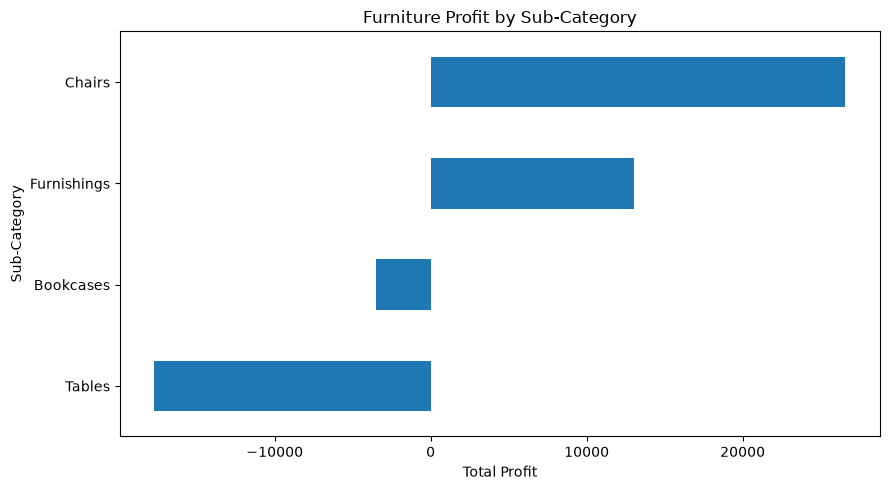

In [19]:
furniture_eda['Profit'].sort_values().plot(kind='barh',figsize=(9,5))
plt.title("Furniture Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

In [20]:
furniture_discount = (
    furniture.groupby("Sub-Category")["Discount"]
    .mean()
    .sort_values(ascending=False)
)

furniture_discount

Sub-Category
Tables         0.261285
Bookcases      0.211140
Chairs         0.170178
Furnishings    0.138349
Name: Discount, dtype: float64

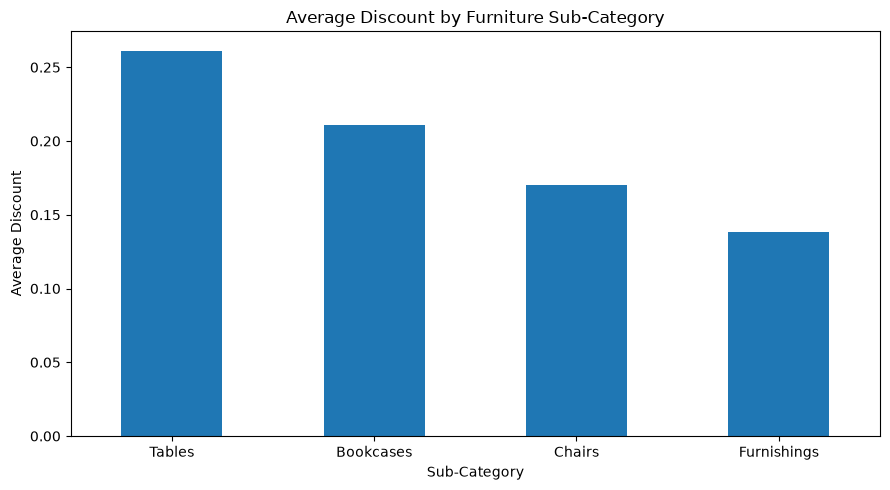

In [21]:
furniture_discount.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Average Discount by Furniture Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Average Discount")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
discount_analysis = df.groupby('Discount').agg(
    Sales = ('Sales','sum'),
    Profit = ('Profit','sum'),
    Orders = ('Order ID','nunique')
)
discount_analysis['Profit Margin'] = (discount_analysis['Profit'] / discount_analysis['Sales']) * 100
discount_analysis


,Sales,Profit,Orders,Profit Margin
Discount,,,,
0.00,1.087908e+06,320987.6032,2644,29.505019
0.10,5.436935e+04,9029.1770,89,16.607108
0.15,2.755852e+04,1418.9915,51,5.149012
0.20,7.645944e+05,90337.3060,2407,11.815063
0.30,1.032267e+05,-10369.2774,211,-10.045155
0.32,1.449346e+04,-2391.1377,27,-16.498047
0.40,1.164178e+05,-23057.0504,185,-19.805437
0.45,5.484974e+03,-2493.1111,10,-45.453472
0.50,5.891854e+04,-20506.4281,64,-34.804712


In [23]:
furniture_region = (
    furniture.groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
)

furniture_region["Profit Margin"] = (
    furniture_region["Profit"]
    / furniture_region["Sales"]
    * 100
)

furniture_region.sort_values(
    "Profit Margin",
    ascending=False
)

,Sales,Profit,Profit Margin
Region,,,
South,117298.6840,6771.2061,5.772619
West,252612.7435,11504.9503,4.554382
East,208291.2040,3046.1658,1.462455
Central,163797.1638,-2871.0494,-1.752808


In [24]:
worst_products = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values("Profit")
      .head(10)
)

worst_products

,Sales,Profit
Product Name,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836
Balt Solid Wood Round Tables,6518.754,-1201.0581


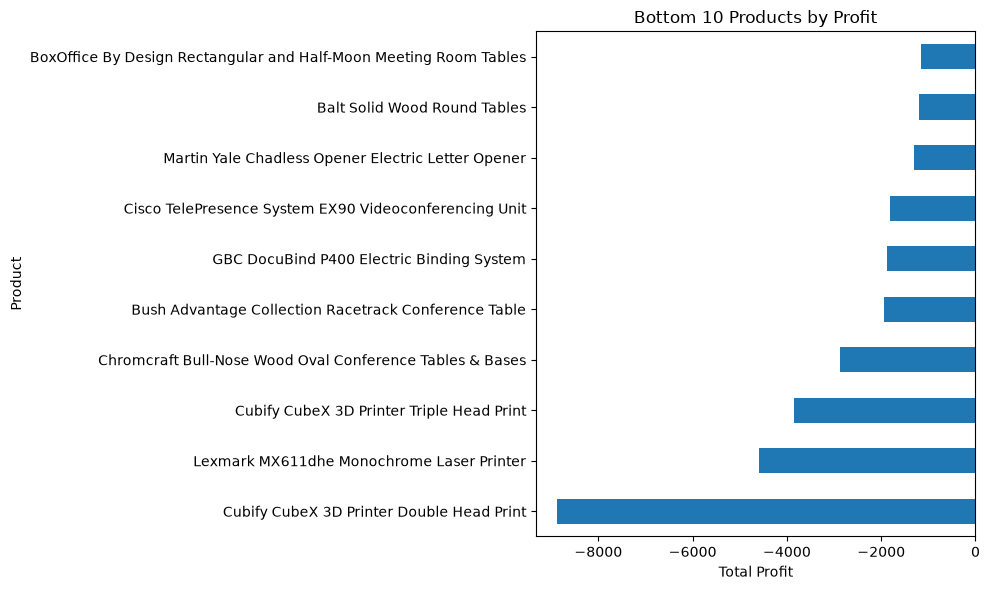

In [25]:
worst_products["Profit"].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Bottom 10 Products by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [26]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Year-Month"] = (
    df["Order Date"]
    .dt.to_period("M")
    .astype(str)
)

In [27]:
monthly_performance = (
    df.groupby("Year-Month")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
)

monthly_performance.head()

,Sales,Profit
Year-Month,,
2014-01,14236.895,2450.1907
2014-02,4519.892,862.3084
2014-03,55691.009,498.7299
2014-04,28295.345,3488.8352
2014-05,23648.287,2738.7096


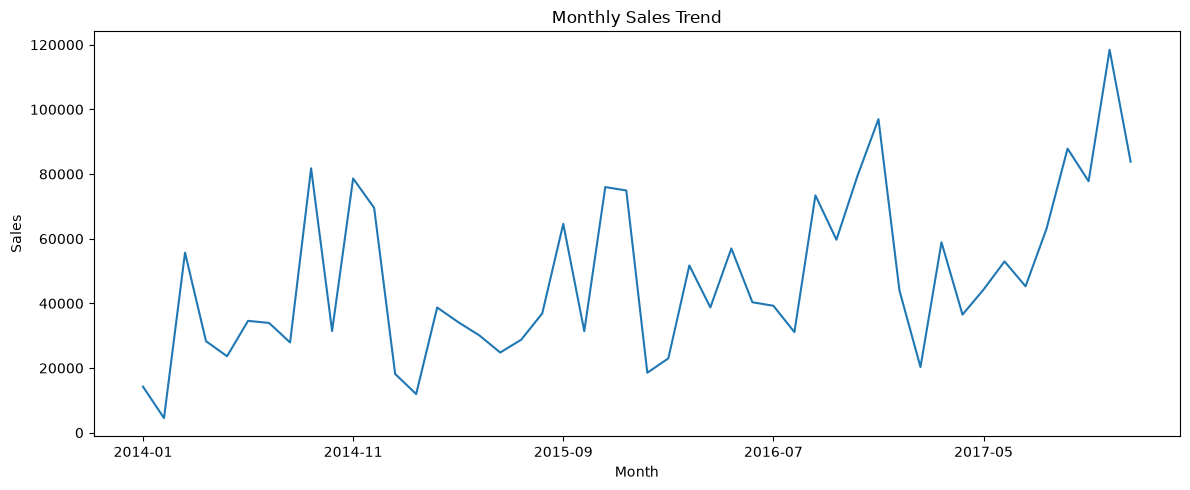

In [28]:
monthly_performance["Sales"].plot(
    figsize=(12,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()